In [1]:
import matplotlib.pyplot as plt
import numpy as np
from distributions import lognormal, constant, truncate
from models import owens_bozic_model
from noise_funcs import proportional_normal_noise
from pipeline_utils import generate_ground_truths
from samplers import independent_sampler
from schedulers import uniform_scheduler

In [99]:
# a (tumor growth rate)
a_dist = truncate(lognormal(0.2, 0.5), high=0.6)

# 1/b (tumor carrying capacity)
# roughly using values from https://www.nature.com/articles/s41586-019-1252-x
b_dist = lambda: 1 / truncate(lognormal(1.37e11, 1.14), high=1e13)()

# dE (max killing rate of effector T cells)
dE_dist = lognormal(2.22, 0.34)

# dC (max killing rate of CAR T_cells)
dC_dist = constant(2.25)

# g (endogenous effector cell source term)
g_dist = constant(1.03e4)

# jE (effector cell recruitment rate)
jE_dist = constant(1.56e-2)

# jC (CAR T-cell recruitment rate)
jC_dist = lognormal(3.46e-1, 0.75)

# K (joint effector cell carrying capacity)
K_dist = constant(5.21e8)

# k (steepness of effector cell recruitment curve)
k_dist = constant(8.67e6)

# l (exponent of tumor lysis by effector cells)
l_dist = lognormal(1.418, 0.15)

# mE (death rate of effector cells)
mE_dist = constant(1.7e-2)

# mC (death rate of CAR T-cells)
mC_dist = constant(2.93e-2)

# qE (effector cell exhaustion)
qE_dist = lognormal(1.28e-10, 1.35)

# qC (CAR T-cell exhaustion)
qC_dist = lognormal(2.14e-10, 2.6)

# s (effector to CAR T-cell ratio for half maximual lysis)
s_dist = truncate(lognormal(0.302, 0.17), high=1)

KT_dist = constant(7e-1)

KE_dist = constant(6e-1)

KC_dist = constant(6e-1)

gamma_dist = constant(9e-1)

T0_dist = lognormal(1.58e9, 1.5)
E0_dist = constant(4e5)
C0_dist = lognormal(6.3e7, 2.0)
M0_dist = lognormal(6.0, 0.2)

param_sampler = independent_sampler(
    [
        a_dist,
        b_dist,
        dE_dist,
        dC_dist,
        g_dist,
        jE_dist,
        jC_dist,
        K_dist,
        k_dist,
        l_dist,
        mE_dist,
        mC_dist,
        qE_dist,
        qC_dist,
        s_dist,
        KT_dist,
        KE_dist,
        KC_dist,
        gamma_dist,
    ]
)

param_names = [
    "a",
    "b",
    "dE",
    "dC",
    "g",
    "jE",
    "jC",
    "K",
    "k",
    "l",
    "mE",
    "mC",
    "qE",
    "qC",
    "s",
    "KT",
    "KE",
    "KC",
    "gamma",
]

initial_conds_sampler = independent_sampler([T0_dist, E0_dist, C0_dist, M0_dist])

In [94]:
from typing import Callable

# for timeseries and parameter sets
type FloatArr = list[float]
# n_obs -> sequence of times
type SchedulerFunc = Callable[[int], FloatArr]
# (n, seed) -> sequence of n sampled parameter sets or initial conditions
type SamplerFunc = Callable[[int, int], list[FloatArr]]
# (observation, seed) -> noisy observation
type NoiseFunc = Callable[[float, int], float]


def plot_trajectories(
    n_indivs: int,
    n_obs: int,
    param_sampler_func: SamplerFunc,
    initial_conditions_func: SamplerFunc,
    schedulers: list[SchedulerFunc],  # one per person
    curve_schedulers: list[
        SchedulerFunc
    ],  # one per person; for plotting smoother curves
    noise_funcs: list[NoiseFunc],  # one per obs var
    seed: int,
    n_obs_curves: int = 100,
    add_noise_flag: bool = True,
    log_scale: bool = False,
    obs_lower_bound: float | None = None,
):
    param_sampler_seed = seed
    initial_conditions_seed = seed + 1023
    sampled_params = param_sampler_func(n_indivs, param_sampler_seed)
    sampled_initial_conditions = initial_conditions_func(
        n_indivs, initial_conditions_seed
    )
    observation_times = [scheduler(n_obs) for scheduler in schedulers]
    ground_truths = generate_ground_truths(
        owens_bozic_model, sampled_params, sampled_initial_conditions, observation_times
    )
    noisy_observations = [
        [
            [
                noise_func(val, seed + 1048575 + len(ground_truth) * i + j)
                for i, (noise_func, val) in enumerate(zip(noise_funcs, row))
            ]
            for j, row in enumerate(ground_truth)
        ]
        for ground_truth in ground_truths
    ]
    if obs_lower_bound is None:
        obs_lower_bound = -float("inf")

    observation_times_curves = [
        scheduler(n_obs_curves) for scheduler in curve_schedulers
    ]
    ground_truths_curves = generate_ground_truths(
        owens_bozic_model,
        sampled_params,
        sampled_initial_conditions,
        observation_times_curves,
    )

    var_names = ["T", "E", "C", "M"]
    # Create a different color for each individual
    colors = plt.cm.Dark2(np.linspace(0, 1, n_indivs))

    # Create one figure per variable
    for i, _ in enumerate(var_names):  # loop over variables (T, E, C, M)
        if var_names[i] not in "TC":
            continue
        plt.figure(figsize=(5, 3))

        plot_func = plt.semilogy if log_scale else plt.plot
        for j in range(n_indivs):  # loop over individuals
            # Plot ground truth as solid line
            plot_func(
                observation_times_curves[j],
                [
                    max(ground_truths_curves[j][t][i], obs_lower_bound)
                    for t in range(len(ground_truths_curves[j]))
                ],
                "-",
                color=colors[j],
                alpha=0.7,
                label=f"{j+1}",
            )
            # plot_func(
            #     observation_times[j],
            #     [
            #         max(ground_truths[j][t][i], obs_lower_bound)
            #         for t in range(len(ground_truths[j]))
            #     ],
            #     "-",
            #     color=colors[j],
            #     alpha=0.3,
            #     linewidth=20,
            #     label=f"{j+1}",
            # )
            # Plot noisy observations as dots
            if add_noise_flag:
                plot_func(
                    observation_times[j],
                    [
                        max(noisy_observations[j][t][i], obs_lower_bound)
                        for t in range(len(noisy_observations[j]))
                    ],
                    "o",
                    color=colors[j],
                    alpha=0.7,
                    label=f"{j+1}",
                )

        plt.ylabel(f"{var_names[i]}(t)")
        plt.xlabel("Time")
        plt.title(f"Variable: {var_names[i]}")
        # plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()

    plt.show()

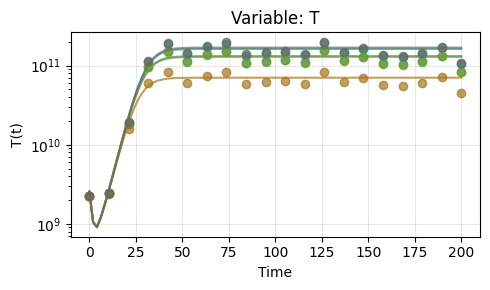

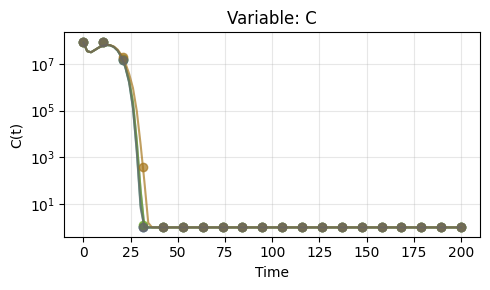

In [95]:
n = 5
n_obs = 20
n_obs_vars = 4
# noise_level = 0.35
noise_level = 0.15
scheduler_funcs = [uniform_scheduler(0, 200) for _ in range(n)]
noise_funcs = [proportional_normal_noise(noise_level, 0) for _ in range(n_obs_vars)]

seed = n + 10
plot_trajectories(
    n_indivs=n,
    n_obs=n_obs,
    param_sampler_func=param_sampler,
    initial_conditions_func=initial_conds_sampler,
    schedulers=scheduler_funcs,
    curve_schedulers=scheduler_funcs,
    noise_funcs=noise_funcs,
    seed=seed,
    log_scale=True,
    obs_lower_bound=1
)

In [97]:
param_sampler(100, seed=42)

[[0.21730160073765545,
  8.602366405789646e-12,
  2.6011384089533625,
  2.25,
  10300.0,
  0.0156,
  0.08105298012575307,
  521000000.0,
  8670000.0,
  1.579258559761253,
  0.017,
  0.0293,
  8.02537373552525e-11,
  3.321438084186007e-11,
  0.3354453445948105,
  0.7,
  0.6,
  0.6,
  0.9],
 [0.21730160073765545,
  8.889621365237966e-12,
  2.6011384089533625,
  2.25,
  10300.0,
  0.0156,
  0.08105298012575307,
  521000000.0,
  8670000.0,
  1.579258559761253,
  0.017,
  0.0293,
  8.02537373552525e-11,
  3.321438084186007e-11,
  0.3354453445948105,
  0.7,
  0.6,
  0.6,
  0.9],
 [0.21730160073765545,
  8.28688740922591e-12,
  2.6011384089533625,
  2.25,
  10300.0,
  0.0156,
  0.08105298012575307,
  521000000.0,
  8670000.0,
  1.579258559761253,
  0.017,
  0.0293,
  8.02537373552525e-11,
  3.321438084186007e-11,
  0.3354453445948105,
  0.7,
  0.6,
  0.6,
  0.9],
 [0.21730160073765545,
  3.2789160871315016e-12,
  2.6011384089533625,
  2.25,
  10300.0,
  0.0156,
  0.08105298012575307,
  521000

In [ ]:
import matplotlib.pyplot as plt

# Get 1000 samples of parameters
param_samples = param_sampler(1000, seed=123)

# Transpose to get a list for each parameter
param_samples_by_param = list(zip(*param_samples))

n_params = len(param_samples_by_param)
fig, axes = plt.subplots(n_params // 4 + (n_params % 4 > 0), 4, figsize=(16, 3 * ((n_params // 4) + 1)))
axes = axes.flatten()

for i, (param_values, name) in enumerate(zip(param_samples_by_param, param_names)):
    print(i)
    axes[i].hist(param_values, bins=30, alpha=0.7)
    axes[i].set_title(f"{name}")
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

KeyboardInterrupt: 